
=== PASSO 1 — BASELINE SE ===
Threshold SE (heurístico): 7.035430080106897e-14
Baseline SE residuals (|r0|): [1.32210968e-15 2.58946282e-15 1.36433401e-13 1.36103312e-13
 2.10082390e-15 6.47960437e-16 5.60662627e-15 8.81649208e-16]

=== PASSO 2 — LINE OUTAGE 1–2 ===
Line-outage SE residuals (|r|): [0.00000000e+00 2.22044605e-15 8.83093091e-14 8.94228857e-14
 2.75340346e-15 1.13883464e-14 1.62506466e-15 4.34983978e-15]

=== PASSO 2 — METER FAILURE (I12 corrompido) ===
Meter-failure SE residuals (|r|): [2.03115573 0.00507841 0.00619511 0.00619511 0.50816024 0.50573811
 0.00502698 0.0050358 ]

=== PASSO 3 — AUTO-REGRESSÃO ===
AR I123 — AR coeff=0.9796, threshold=0.002758, anomalies=0, frozen groups=0
AR V3   — AR coeff=0.9642, threshold=0.078772, anomalies=0, frozen groups=0

=== PASSO 4 — ABNORMAL LOAD (bus 2 × 2.0) ===

=== PASSO 4 — POWER FLOW FAULT (factor 1.5) ===

=== PASSO 5 — AR EM FALHAS (SPIKE & FROZEN) ===

=== VETORES DE OBSERVAÇÃO (para HMM) ===
  normal              : [6.81

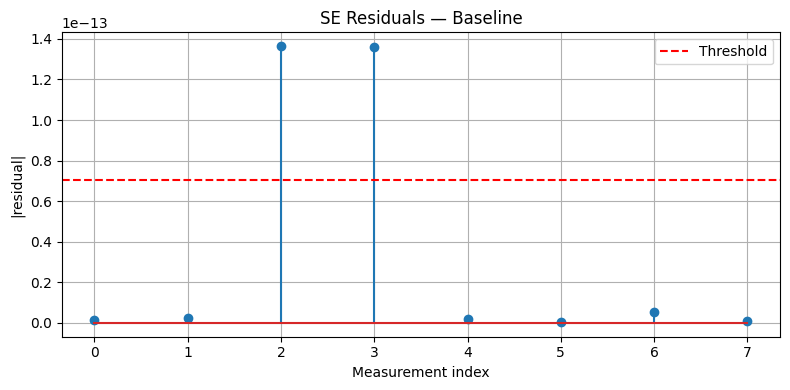

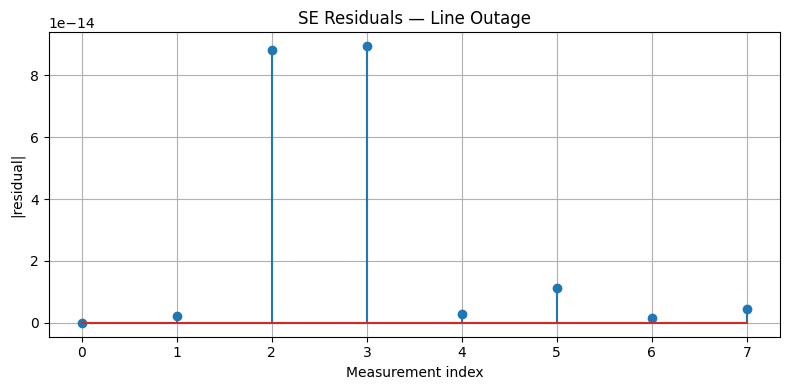

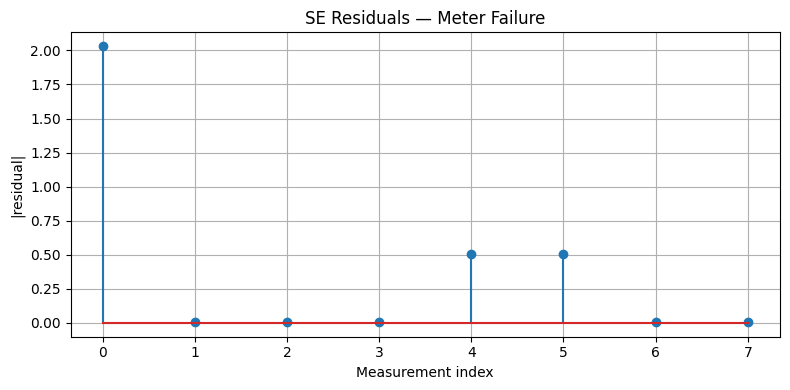

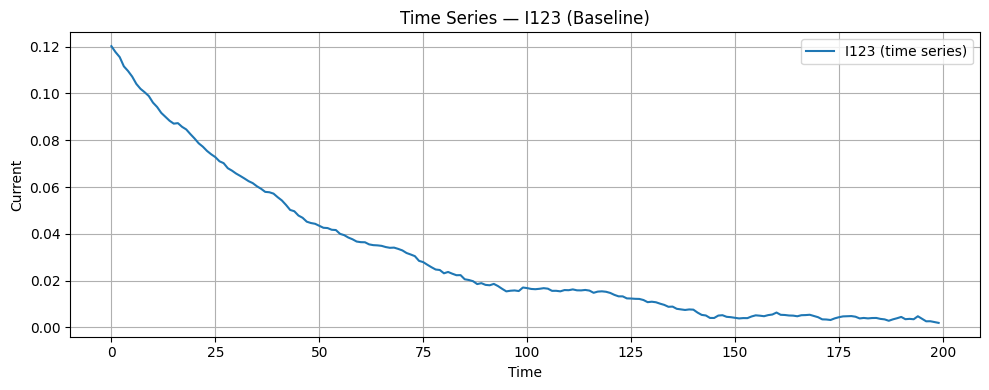

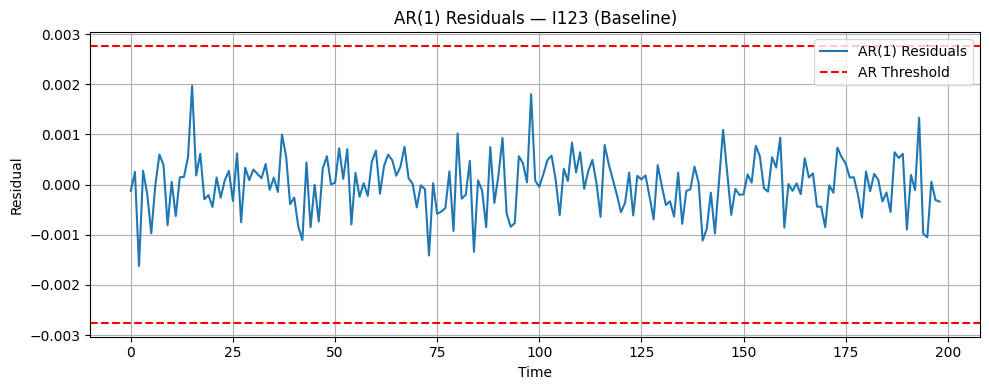

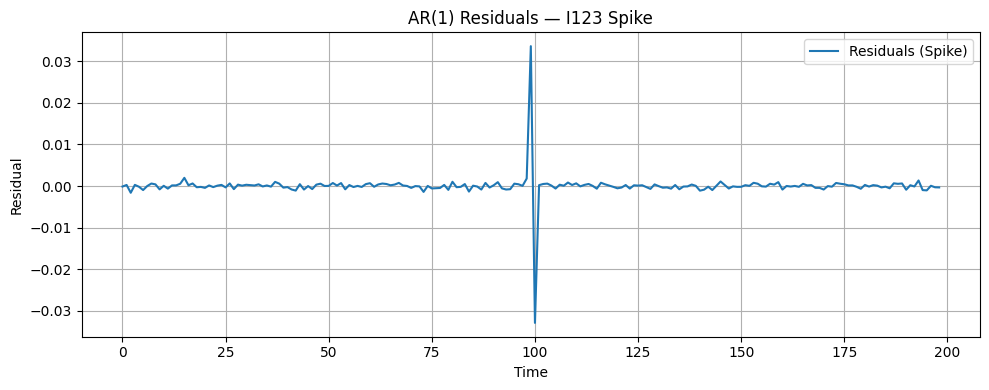

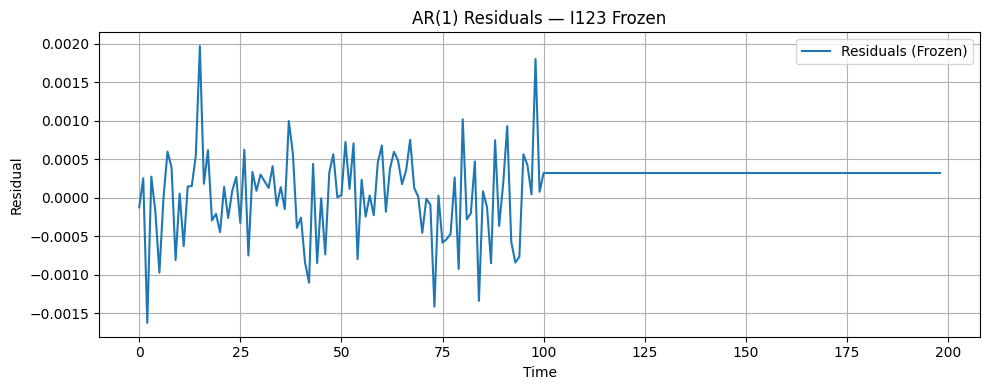

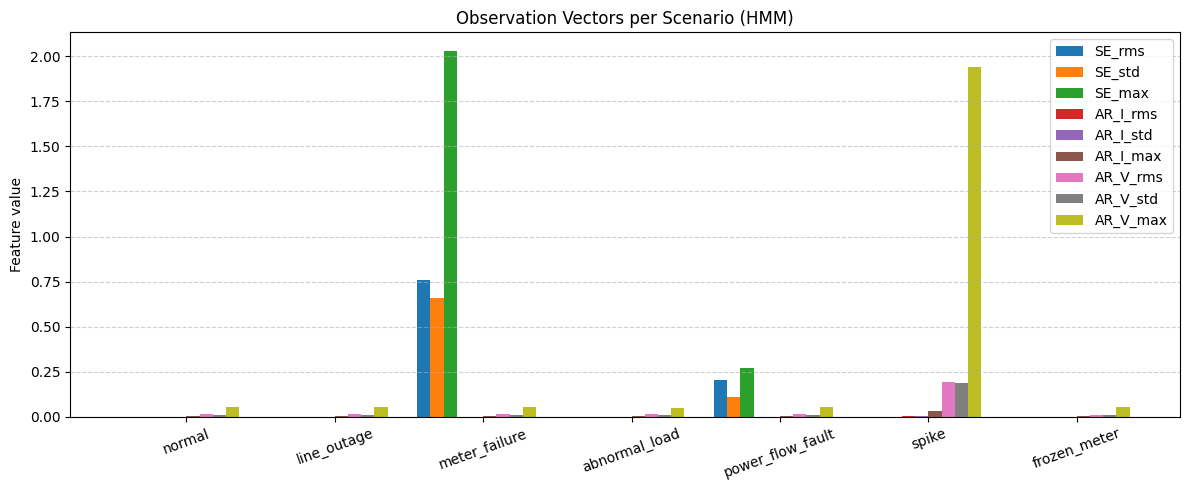


HMM — Classification Results

Scenario : normal
  Clean  obs : [6.81759513e-14 5.80750248e-14 1.36433401e-13 5.51683611e-04
 3.53630344e-04 1.96698124e-03 1.57544337e-02 9.53566663e-03
 5.33426124e-02]
  Classified : line_outage
  Noisy  obs : [-0.20262169  0.10383377 -0.08834245  0.03649911  0.27797887 -0.09692658
  0.00307496  0.02739186  0.13439987]
  Classified : normal

Scenario : line_outage
  Clean  obs : [4.46636801e-14 3.70055557e-14 8.94228857e-14 5.51683611e-04
 3.53630344e-04 1.96698124e-03 1.57544337e-02 9.53566663e-03
 5.33426124e-02]
  Classified : line_outage
  Noisy  obs : [-0.15547248 -0.1990516  -0.01829174  0.15971047 -0.10277565  0.07679359
  0.03882042 -0.02430206 -0.19090931]
  Classified : abnormal_load

Scenario : meter_failure
  Clean  obs : [7.61556353e-01 6.57613766e-01 2.03115573e+00 5.51683611e-04
 3.53630344e-04 1.96698124e-03 1.57544337e-02 9.53566663e-03
 5.33426124e-02]
  Classified : meter_failure
  Noisy  obs : [ 0.59286263  0.70973991  1.92578857 -

In [15]:
import numpy as np
import pandas as pd

# ============================================================
# CONSTANTS  [FIX: magic numbers centralised here]
# ============================================================
NETWORK_FACTOR   = 100
COS_PHI          = 0.95
TIME_STEPS       = 200          # AR time-series length
AR_NOISE_STD     = 0.05         # std of complex noise in time series
AR_ANOMALY_FACTOR = 5           # threshold = factor * std(residual)
FROZEN_WINDOW    = 10           # min consecutive flat samples to flag frozen
METER_CORRUPTION = 20           # multiplier for meter-failure simulation
LOAD_SCALE       = 2.0          # abnormal-load scale factor (bus 2)
PF_FACTOR        = 1.5          # power-flow-fault voltage scale
SPIKE_FACTOR     = 3.0          # AR spike magnitude factor
SPIKE_T          = 100          # time step of spike
FROZEN_T         = 100          # time step where freeze begins
HMM_SELF_PROB    = 0.90         # HMM diagonal transition probability
HMM_NOISE_LEVEL  = 0.2          # noise level for noisy classification test
SE_THR_FACTOR    = 30           # SE threshold = factor * median(|r0|)
# [FIX: load-time-step index is explicit, not buried in load_network]
LOAD_TIME_STEP   = 2            # which row of Load(t,Bus) to use as I


# ============================================================
# 0. CARREGAR REDE E CONSTRUIR MATRIZ Y
# ============================================================

def load_network(networkFactor=NETWORK_FACTOR, cosPhi=COS_PHI):
    # [FIX: read Excel once, store all sheets, then extract — avoids reading
    #  the file multiple times]
    xl = pd.ExcelFile('DASG_Prob2_new.xlsx')
    Info      = np.array(xl.parse('Info',        header=None))
    Net_Info  = np.array(xl.parse('Y_Data'))
    Power_raw = np.array(xl.parse('Load(t,Bus)'))

    SlackBus   = int(Info[0, 1])
    Power_Info = np.delete(Power_raw, [0], axis=1)

    P = -Power_Info * np.exp(1j * np.arccos(cosPhi))
    # [FIX: LOAD_TIME_STEP is now a named constant so the choice is explicit]
    I = np.conj(P[LOAD_TIME_STEP, :])

    nBus = int(max(np.max(Net_Info[:, 0]), np.max(Net_Info[:, 1])))
    Y = np.zeros((nBus, nBus), dtype=complex)

    for i in range(Net_Info.shape[0]):
        y_aux = Net_Info[i, 2].replace(",", ".").replace("i", "j")
        y = complex(y_aux) * networkFactor
        a = int(Net_Info[i, 0]) - 1
        b = int(Net_Info[i, 1]) - 1
        Y[a, a] += y
        Y[b, b] += y
        Y[a, b] -= y
        Y[b, a] -= y

    return Y, SlackBus, I


# ============================================================
# HELPER: solve voltages from Y and I (excluding slack)
# ============================================================

def _solve_voltages(Y, SlackBus, I):
    """Return full voltage vector given admittance matrix, slack bus, and
    injected currents (slack bus excluded from the system solve)."""
    nBus = Y.shape[0]
    slack_idx = SlackBus - 1

    Yl = np.delete(np.delete(Y, slack_idx, axis=0), slack_idx, axis=1)

    v = np.zeros(nBus, dtype=complex)
    v[np.arange(nBus) != slack_idx] = 1.0 + np.linalg.solve(Yl, I)
    v[slack_idx] = 1.0
    return v


# ============================================================
# HELPER: build H matrix from admittance matrix
# [FIX: H construction was duplicated in compute_baseline and run_SE;
#  now lives in one place]
# ============================================================

def _build_H(Y):
    """Build the 8×5 measurement Jacobian H for the 5-bus kite grid."""
    y12 = -Y[0, 1]
    y13 = -Y[0, 2]
    y23 = -Y[1, 2]
    y34 = -Y[2, 3]
    y45 = -Y[3, 4]

    Hx = np.zeros((8, 5), dtype=complex)
    # Line current measurements
    Hx[0, 0] =  y12;  Hx[0, 1] = -y12
    Hx[1, 3] = -y45;  Hx[1, 4] =  y45
    # Voltage measurements
    Hx[2, 1] = 1
    Hx[3, 4] = 1
    # Nodal current injections (KCL rows)
    Hx[4, 0] =  y12 + y13;  Hx[4, 1] = -y12;  Hx[4, 2] = -y13
    Hx[5, 0] = -y12;         Hx[5, 1] =  y12 + y23;  Hx[5, 2] = -y23
    Hx[6, 0] = -y13;         Hx[6, 1] = -y23
    Hx[6, 2] =  y13 + y23 + y34;  Hx[6, 3] = -y34
    Hx[7, 2] = -y34;  Hx[7, 3] =  y34 + y45;  Hx[7, 4] = -y45
    return Hx


# ============================================================
# HELPER: weighted-least-squares SE solve
# ============================================================

def _wls_solve(Hx, z):
    """Return estimated state x and residual r = z - H x."""
    HtH = Hx.conj().T @ Hx
    x   = np.linalg.solve(HtH, Hx.conj().T @ z)
    r   = z - Hx @ x
    return x, r


# ============================================================
# 1. PASSO 1 — BASELINE SE
# ============================================================

def compute_baseline(Y, SlackBus, I):
    v0 = _solve_voltages(Y, SlackBus, I)

    y12 = -Y[0, 1]
    y45 = -Y[3, 4]

    z0 = np.zeros(8, dtype=complex)
    z0[0]   = y12 * (v0[0] - v0[1])
    z0[1]   = y45 * (v0[4] - v0[3])
    z0[2]   = v0[1]
    z0[3]   = v0[4]
    z0[4:8] = I

    Hx      = _build_H(Y)
    x0, r0  = _wls_solve(Hx, z0)

    return v0, z0, Hx, x0, r0


# ============================================================
# 2. PASSO 2 — DETEÇÃO DE FALHAS (SE)
# ============================================================

def simulate_line_outage(Y, line):
    """Remove a line from the admittance matrix, correctly updating both
    off-diagonal and diagonal entries.
    [FIX: original only zeroed off-diagonal, leaving diagonal wrong]"""
    a, b = line
    y_line = -Y[a, b]          # recover the admittance of this branch
    Y_fault = Y.copy()
    Y_fault[a, b]  = 0
    Y_fault[b, a]  = 0
    Y_fault[a, a] -= y_line    # remove branch contribution from shunt
    Y_fault[b, b] -= y_line
    return Y_fault


def simulate_meter_failure(z0, index, corruption=METER_CORRUPTION):
    z_fault = z0.copy()
    z_fault[index] *= corruption
    return z_fault


def run_SE(Y, SlackBus, I, z):
    """Run state estimation for an arbitrary measurement vector z.
    [FIX: now uses shared _build_H / _wls_solve helpers instead of
     duplicating the H construction]"""
    Hx     = _build_H(Y)
    x, r   = _wls_solve(Hx, z)
    return x, r


# ============================================================
# 3. PASSO 3 — AUTO-REGRESSÃO (AR)
# ============================================================

def generate_time_series(Y, SlackBus, I, time=TIME_STEPS):
    slack_idx = SlackBus - 1
    Yl = np.delete(np.delete(Y, slack_idx, axis=0), slack_idx, axis=1)
    nFree = Yl.shape[0]

    II    = np.zeros((nFree, time), dtype=complex)
    I123  = np.zeros(time)
    V3    = np.zeros(time)

    II[:, 0] = I
    v = 1.0 + np.linalg.solve(Yl, I)
    I123[0] = np.abs(Y[0, 1] * (v[0] - v[1]))
    V3[0]   = np.abs(v[2])

    # [FIX: noise is now complex so it perturbs both real and imaginary parts
    #  of the current injection symmetrically]
    rng = np.random.default_rng()
    e = (rng.standard_normal(time) + 1j * rng.standard_normal(time)) * AR_NOISE_STD

    for t in range(time - 1):
        II[:, t + 1] = 0.98 * II[:, t] + e[t]
        v = 1.0 + np.linalg.solve(Yl, II[:, t + 1])
        I123[t + 1] = np.abs(Y[0, 1] * (v[0] - v[1]))
        V3[t + 1]   = np.abs(v[2])

    return I123, V3


def fit_AR1(x):
    x_t   = x[1:]
    x_tm1 = x[:-1]
    A     = np.column_stack([x_tm1, np.ones(len(x_tm1))])
    a, b  = np.linalg.lstsq(A, x_t, rcond=None)[0]
    return a, b


def compute_residuals(x, a, b):
    x_hat = a * x[:-1] + b
    r     = x[1:] - x_hat
    return r, x_hat


def detect_anomalies(r, factor=AR_ANOMALY_FACTOR):
    thr       = factor * np.std(r)
    anomalies = np.where(np.abs(r) > thr)[0]
    return anomalies, thr


def detect_frozen_meter(x, window=FROZEN_WINDOW):
    diffs  = np.abs(np.diff(x))
    frozen = np.where(diffs < 1e-4)[0]

    groups, current = [], []
    for idx in frozen:
        if not current or idx == current[-1] + 1:
            current.append(idx)
        else:
            if len(current) >= window:
                groups.append(current)
            current = [idx]
    if len(current) >= window:
        groups.append(current)

    return groups


# ============================================================
# 4. PASSO 4 — SIMULAÇÃO DE FALHAS
# ============================================================

def simulate_abnormal_load(I, bus, scale):
    I_fault      = I.copy()
    I_fault[bus] *= scale
    return I_fault


def simulate_power_flow_fault(Y, SlackBus, I, factor=PF_FACTOR):
    v       = _solve_voltages(Y, SlackBus, I)
    v_fault = v * factor

    y12 = -Y[0, 1]
    y45 = -Y[3, 4]

    z_fault      = np.zeros(8, dtype=complex)
    z_fault[0]   = y12 * (v_fault[0] - v_fault[1])
    z_fault[1]   = y45 * (v_fault[4] - v_fault[3])
    z_fault[2]   = v_fault[1]
    z_fault[3]   = v_fault[4]
    z_fault[4:8] = I
    return z_fault


# ============================================================
# 5. PASSO 5 — RESÍDUOS EM FALHAS & VETORES DE OBSERVAÇÃO
# ============================================================

def simulate_AR_spike(x, t_spike=SPIKE_T, factor=SPIKE_FACTOR):
    x_fault          = x.copy()
    x_fault[t_spike] *= factor
    return x_fault


def simulate_AR_frozen(x, t_start=FROZEN_T):
    x_fault          = x.copy()
    x_fault[t_start:] = x_fault[t_start]
    return x_fault


def residual_features(r):
    """Summarise a residual array as [rms, std, max_abs].
    [FIX: original used only max(|r|), which is fragile to single outliers;
     RMS + std + max gives a richer, more robust feature vector]"""
    abs_r = np.abs(r)
    return np.array([
        np.sqrt(np.mean(abs_r ** 2)),   # RMS
        np.std(abs_r),                  # spread
        np.max(abs_r),                  # peak
    ])


def build_observation_vector(se_residual, ar_I_residual=None, ar_V_residual=None):
    """Build the observation vector fed into the HMM.
    Each residual source contributes 3 features (rms, std, max).
    [FIX: was a single max() per source — now 3 features per source]"""
    parts = [residual_features(se_residual)]
    if ar_I_residual is not None:
        parts.append(residual_features(ar_I_residual))
    if ar_V_residual is not None:
        parts.append(residual_features(ar_V_residual))
    return np.concatenate(parts).real   # observations are real-valued


# ============================================================
# 6. PASSO 6 — HMM PARA CLASSIFICAÇÃO DE FALHAS
#
# Architecture: discrete-time HMM with Gaussian emission.
# Training: one sequence per fault class → estimate mean & covariance
#           of the observation vector for that class.
# Decoding:  Viterbi algorithm over a sequence of observations.
#
# [FIX: original stored one point per state and used nearest-centroid
#  lookup, ignoring the transition matrix A entirely.
#  Now:
#   - hmm_train  stores per-state Gaussian parameters (mean, cov).
#   - hmm_viterbi runs a proper Viterbi decode over a sequence.
#   - hmm_classify_single still works for a single observation
#     (useful for quick checks / noisy tests).]
# ============================================================

def _gaussian_log_likelihood(obs, mean, cov):
    """Log-likelihood of obs under N(mean, cov)."""
    d     = obs - mean
    sign, logdet = np.linalg.slogdet(cov)
    if sign <= 0:
        return -np.inf
    maha  = d @ np.linalg.solve(cov, d)
    k     = len(obs)
    return -0.5 * (k * np.log(2 * np.pi) + logdet + maha)


def hmm_train(observations_dict, n_fake_samples=50, obs_noise_std=0.05):
    """Estimate HMM parameters from one prototype observation per state.

    Because we have only one real sample per state we synthesise
    n_fake_samples noisy copies to estimate the covariance.

    Returns
    -------
    states : list of str
    A      : (n_states, n_states) transition matrix
    means  : (n_states, d) array of per-state means
    covs   : list of (d, d) covariance matrices
    """
    states   = list(observations_dict.keys())
    n_states = len(states)
    n_obs    = len(next(iter(observations_dict.values())))

    means = np.array([observations_dict[s] for s in states])   # (n_states, d)
    covs  = []

    rng = np.random.default_rng(seed=0)
    for s in states:
        proto  = observations_dict[s]
        samples = proto + rng.standard_normal((n_fake_samples, n_obs)) * obs_noise_std
        covs.append(np.cov(samples.T) + np.eye(n_obs) * 1e-6)   # regularise

    # Transition matrix: high self-loop probability, equal off-diagonal
    off = (1.0 - HMM_SELF_PROB) / max(n_states - 1, 1)
    A   = np.full((n_states, n_states), off)
    np.fill_diagonal(A, HMM_SELF_PROB)

    return states, A, means, covs


def hmm_viterbi(obs_sequence, states, A, means, covs, pi=None):
    """Viterbi decode a sequence of observation vectors.

    Parameters
    ----------
    obs_sequence : (T, d) array — T observations of dimension d
    pi           : (n_states,) initial state distribution (uniform if None)

    Returns
    -------
    best_path  : list of str state labels
    log_probs  : (T, n_states) Viterbi log-probability table
    """
    T        = len(obs_sequence)
    n_states = len(states)
    log_A    = np.log(A + 1e-300)

    if pi is None:
        log_pi = np.full(n_states, -np.log(n_states))
    else:
        log_pi = np.log(pi + 1e-300)

    # Emission log-likelihoods for every (t, state)
    log_B = np.array([
        [_gaussian_log_likelihood(obs_sequence[t], means[s], covs[s])
         for s in range(n_states)]
        for t in range(T)
    ])                                        # (T, n_states)

    # Forward pass
    delta   = np.zeros((T, n_states))
    psi     = np.zeros((T, n_states), dtype=int)
    delta[0] = log_pi + log_B[0]

    for t in range(1, T):
        for s in range(n_states):
            trans = delta[t - 1] + log_A[:, s]
            psi[t, s]   = np.argmax(trans)
            delta[t, s] = trans[psi[t, s]] + log_B[t, s]

    # Back-track
    path = [int(np.argmax(delta[-1]))]
    for t in range(T - 1, 0, -1):
        path.append(psi[t, path[-1]])
    path.reverse()

    return [states[s] for s in path], delta


def hmm_classify_single(obs, states, A, means, covs):
    """Classify a single observation by Gaussian emission likelihood only
    (no sequence context).  Convenient for spot-checks."""
    lls       = np.array([_gaussian_log_likelihood(obs, means[i], covs[i])
                          for i in range(len(states))])
    best      = np.argmax(lls)
    return states[best], lls


# ============================================================
# 7. PLOTTING HELPERS
# [FIX: plotting moved into a dedicated function so __main__ stays clean]
# ============================================================

def plot_results(r0, thr_SE,
                 r_fault, r_fault2,
                 I123, r_I, thr_I,
                 r_I_spike, r_I_frozen,
                 observations,
                 hmm_results):
    import matplotlib.pyplot as plt

    # 1) SE — Baseline
    plt.figure(figsize=(8, 4))
    plt.stem(np.abs(r0))
    plt.axhline(thr_SE, color='red', linestyle='--', label='Threshold')
    plt.title("SE Residuals — Baseline")
    plt.xlabel("Measurement index"); plt.ylabel("|residual|")
    plt.legend(); plt.grid(True); plt.tight_layout(); plt.show()

    # 2) SE — Line Outage
    plt.figure(figsize=(8, 4))
    plt.stem(np.abs(r_fault))
    plt.title("SE Residuals — Line Outage")
    plt.xlabel("Measurement index"); plt.ylabel("|residual|")
    plt.grid(True); plt.tight_layout(); plt.show()

    # 3) SE — Meter Failure
    plt.figure(figsize=(8, 4))
    plt.stem(np.abs(r_fault2))
    plt.title("SE Residuals — Meter Failure")
    plt.xlabel("Measurement index"); plt.ylabel("|residual|")
    plt.grid(True); plt.tight_layout(); plt.show()

    # 4) AR time series and residuals
    plt.figure(figsize=(10, 4))
    plt.plot(I123, label="I123 (time series)")
    plt.title("Time Series — I123 (Baseline)")
    plt.xlabel("Time"); plt.ylabel("Current")
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(r_I, label="AR(1) Residuals")
    plt.axhline(thr_I,  color='red', linestyle='--', label='AR Threshold')
    plt.axhline(-thr_I, color='red', linestyle='--')
    plt.title("AR(1) Residuals — I123 (Baseline)")
    plt.xlabel("Time"); plt.ylabel("Residual")
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(r_I_spike, label="Residuals (Spike)")
    plt.title("AR(1) Residuals — I123 Spike")
    plt.xlabel("Time"); plt.ylabel("Residual")
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    plt.figure(figsize=(10, 4))
    plt.plot(r_I_frozen, label="Residuals (Frozen)")
    plt.title("AR(1) Residuals — I123 Frozen")
    plt.xlabel("Time"); plt.ylabel("Residual")
    plt.grid(True); plt.legend(); plt.tight_layout(); plt.show()

    # 5) HMM — Observation Vectors (3 features per source → 9 total)
    states_list = list(observations.keys())
    obs_matrix  = np.array([observations[s] for s in states_list])
    n_feat      = obs_matrix.shape[1]
    labels      = (["SE_rms", "SE_std", "SE_max"] +
                   ["AR_I_rms", "AR_I_std", "AR_I_max"] +
                   ["AR_V_rms", "AR_V_std", "AR_V_max"])[:n_feat]

    x     = np.arange(len(states_list))
    width = 0.8 / n_feat
    plt.figure(figsize=(12, 5))
    for fi in range(n_feat):
        plt.bar(x + fi * width - 0.4, obs_matrix[:, fi], width, label=labels[fi])
    plt.xticks(x, states_list, rotation=20)
    plt.ylabel("Feature value"); plt.title("Observation Vectors per Scenario (HMM)")
    plt.legend(); plt.grid(axis='y', linestyle='--', alpha=0.6)
    plt.tight_layout(); plt.show()

    # 6) HMM classification results
    print("\nHMM — Classification Results")
    for scenario, (state_clean, state_noisy, obs_clean, obs_noisy) in hmm_results.items():
        print(f"\nScenario : {scenario}")
        print(f"  Clean  obs : {obs_clean}")
        print(f"  Classified : {state_clean}")
        print(f"  Noisy  obs : {obs_noisy}")
        print(f"  Classified : {state_noisy}")


# ============================================================
# 8. EXECUTAR PROJECTO COMPLETO
# ============================================================

if __name__ == "__main__":

    # ── 0. Load network ──────────────────────────────────────
    Y, SlackBus, I = load_network()

    # ── 1. Baseline SE ───────────────────────────────────────
    print("\n=== PASSO 1 — BASELINE SE ===")
    v0, z0, Hx, x0, r0 = compute_baseline(Y, SlackBus, I)
    thr_SE = SE_THR_FACTOR * np.median(np.abs(r0))
    print("Threshold SE (heurístico):", thr_SE)
    print("Baseline SE residuals (|r0|):", np.abs(r0))

    # ── 2. SE fault scenarios ────────────────────────────────
    print("\n=== PASSO 2 — LINE OUTAGE 1–2 ===")
    Y_fault    = simulate_line_outage(Y, (0, 1))
    # Re-compute z for the faulted topology so measurements are consistent
    v_fault_lo = _solve_voltages(Y_fault, SlackBus, I)
    y12_f      = -Y_fault[0, 1]          # = 0 after outage
    y45_f      = -Y_fault[3, 4]
    z_fault_lo = np.zeros(8, dtype=complex)
    z_fault_lo[0]   = y12_f * (v_fault_lo[0] - v_fault_lo[1])
    z_fault_lo[1]   = y45_f * (v_fault_lo[4] - v_fault_lo[3])
    z_fault_lo[2]   = v_fault_lo[1]
    z_fault_lo[3]   = v_fault_lo[4]
    z_fault_lo[4:8] = I
    x_fault, r_fault = run_SE(Y_fault, SlackBus, I, z_fault_lo)
    print("Line-outage SE residuals (|r|):", np.abs(r_fault))

    print("\n=== PASSO 2 — METER FAILURE (I12 corrompido) ===")
    z_fault_mf        = simulate_meter_failure(z0, 0, corruption=METER_CORRUPTION)
    x_fault2, r_fault2 = run_SE(Y, SlackBus, I, z_fault_mf)
    print("Meter-failure SE residuals (|r|):", np.abs(r_fault2))

    # ── 3. AR baseline ───────────────────────────────────────
    print("\n=== PASSO 3 — AUTO-REGRESSÃO ===")
    I123, V3 = generate_time_series(Y, SlackBus, I)

    a_I, b_I         = fit_AR1(I123)
    r_I, _           = compute_residuals(I123, a_I, b_I)
    anomalies_I, thr_I = detect_anomalies(r_I)
    frozen_I         = detect_frozen_meter(I123)

    a_V, b_V         = fit_AR1(V3)
    r_V, _           = compute_residuals(V3, a_V, b_V)
    anomalies_V, thr_V = detect_anomalies(r_V)
    frozen_V         = detect_frozen_meter(V3)

    print(f"AR I123 — AR coeff={a_I:.4f}, threshold={thr_I:.6f}, "
          f"anomalies={len(anomalies_I)}, frozen groups={len(frozen_I)}")
    print(f"AR V3   — AR coeff={a_V:.4f}, threshold={thr_V:.6f}, "
          f"anomalies={len(anomalies_V)}, frozen groups={len(frozen_V)}")

    # ── 4. Additional fault scenarios ────────────────────────
    print("\n=== PASSO 4 — ABNORMAL LOAD (bus 2 × 2.0) ===")
    I_abnormal           = simulate_abnormal_load(I, bus=1, scale=LOAD_SCALE)
    v_ab, z_ab, _, x_ab, r_ab = compute_baseline(Y, SlackBus, I_abnormal)
    I123_ab, V3_ab       = generate_time_series(Y, SlackBus, I_abnormal)
    a_I_ab, b_I_ab       = fit_AR1(I123_ab)
    r_I_ab, _            = compute_residuals(I123_ab, a_I_ab, b_I_ab)
    a_V_ab, b_V_ab       = fit_AR1(V3_ab)
    r_V_ab, _            = compute_residuals(V3_ab, a_V_ab, b_V_ab)

    print("\n=== PASSO 4 — POWER FLOW FAULT (factor 1.5) ===")
    z_pf         = simulate_power_flow_fault(Y, SlackBus, I, factor=PF_FACTOR)
    x_pf, r_pf  = run_SE(Y, SlackBus, I, z_pf)

    # ── 5. AR fault scenarios (spike & frozen) ───────────────
    print("\n=== PASSO 5 — AR EM FALHAS (SPIKE & FROZEN) ===")

    I123_spike  = simulate_AR_spike(I123,  t_spike=SPIKE_T, factor=SPIKE_FACTOR)
    r_I_spike, _ = compute_residuals(I123_spike, a_I, b_I)

    V3_spike    = simulate_AR_spike(V3,    t_spike=SPIKE_T, factor=SPIKE_FACTOR)
    r_V_spike, _ = compute_residuals(V3_spike,  a_V, b_V)

    I123_frozen  = simulate_AR_frozen(I123, t_start=FROZEN_T)
    r_I_frozen, _ = compute_residuals(I123_frozen, a_I, b_I)

    V3_frozen    = simulate_AR_frozen(V3,   t_start=FROZEN_T)
    r_V_frozen, _ = compute_residuals(V3_frozen,  a_V, b_V)

    # ── 5b. Build observation vectors ───────────────────────
    observations = {
        "normal"          : build_observation_vector(r0,      r_I,       r_V),
        "line_outage"     : build_observation_vector(r_fault,  r_I,       r_V),
        "meter_failure"   : build_observation_vector(r_fault2, r_I,       r_V),
        "abnormal_load"   : build_observation_vector(r_ab,     r_I_ab,    r_V_ab),
        "power_flow_fault": build_observation_vector(r_pf,     r_I,       r_V),
        "spike"           : build_observation_vector(r0,       r_I_spike, r_V_spike),
        "frozen_meter"    : build_observation_vector(r0,       r_I_frozen,r_V_frozen),
    }

    print("\n=== VETORES DE OBSERVAÇÃO (para HMM) ===")
    for k, v in observations.items():
        print(f"  {k:20s}: {v}")

    # ── 6. HMM training & classification ────────────────────
    print("\n=== PASSO 6 — HMM PARA CLASSIFICAÇÃO DE FALHAS ===")

    states, A, means, covs = hmm_train(observations)

    hmm_results = {}
    rng = np.random.default_rng()

    for scenario, obs in observations.items():
        # Single-observation classification (clean)
        state_clean, _ = hmm_classify_single(obs, states, A, means, covs)

        # Single-observation classification (noisy)
        obs_noisy   = obs + rng.standard_normal(obs.shape) * HMM_NOISE_LEVEL
        state_noisy, _ = hmm_classify_single(obs_noisy, states, A, means, covs)

        hmm_results[scenario] = (state_clean, state_noisy, obs, obs_noisy)

        print(f"\nScenario : {scenario}")
        print(f"  Obs (clean) : {obs}")
        print(f"  Class       : {state_clean}")
        print(f"  Obs (noisy) : {obs_noisy}")
        print(f"  Class       : {state_noisy}")

    # ── Demo of Viterbi over a short sequence ───────────────
    print("\n=== VITERBI DEMO (sequence of 5 observations) ===")
    # Build a short sequence: normal × 3, then spike × 2
    demo_seq = np.array([
        observations["normal"],
        observations["normal"],
        observations["normal"],
        observations["spike"],
        observations["spike"],
    ])
    path, _ = hmm_viterbi(demo_seq, states, A, means, covs)
    print("Input labels : normal, normal, normal, spike, spike")
    print("Viterbi path :", path)

    # ── Uncomment to display plots ───────────────────────────
    plot_results(
         r0, thr_SE,
         r_fault, r_fault2,
         I123, r_I, thr_I,
         r_I_spike, r_I_frozen,
         observations,
         hmm_results)


# ============================================================
# CONSTANTS -- HMM SIMULATION
# ============================================================
MEAS_NOISE_STD  = 0.01   # realistic meter noise (~1%)
AR_COEFF        = 0.98   # AR(1) coefficient
SIM_SEED        = 42
SIM_T_PER_STATE = 80     # steps per fault segment

STATE_NAMES = [
    "normal", "line_outage", "meter_failure",
    "abnormal_load", "power_flow_fault", "spike", "frozen_meter",
]

# 5 features per time step: [SE_norm, I12_mag, V2_mag, I_bus2, AR_res_I12]
FEAT_NAMES = ['SE_norm', 'I12_mag', 'V2_mag', 'I_bus2', 'AR_res_I12']

# Physics-derived emission means.
# spike: I12 = 3x baseline at the spike step, large AR residual.
# frozen_meter: I12 stays constant => AR residual collapses to ~0.
HMM_MEANS = {
    "normal"          : [0.023, 0.136, 1.000, 0.265, 0.018],
    "line_outage"     : [0.023, 0.000, 1.000, 0.232, 0.002],
    "meter_failure"   : [1.428, 0.084, 1.000, 0.207, 0.022],
    "abnormal_load"   : [0.024, 0.235, 1.001, 0.627, 0.026],
    "power_flow_fault": [0.028, 0.160, 1.000, 0.326, 0.019],
    "spike"           : [0.023, 0.303, 1.000, 0.283, 0.250],
    "frozen_meter"    : [0.023, 0.022, 1.001, 0.241, 0.001],
}

# Per-state diagonal covariances (variance = std^2 per feature).
HMM_COVARS = {
    "normal"          : [0.004**2, 0.015**2, 0.005**2, 0.020**2, 0.010**2],
    "line_outage"     : [0.004**2, 0.001**2, 0.005**2, 0.020**2, 0.002**2],
    "meter_failure"   : [0.300**2, 0.030**2, 0.010**2, 0.020**2, 0.010**2],
    "abnormal_load"   : [0.004**2, 0.020**2, 0.005**2, 0.050**2, 0.015**2],
    "power_flow_fault": [0.005**2, 0.015**2, 0.010**2, 0.030**2, 0.010**2],
    "spike"           : [0.004**2, 0.050**2, 0.005**2, 0.030**2, 0.080**2],
    "frozen_meter"    : [0.004**2, 0.010**2, 0.005**2, 0.020**2, 0.002**2],
}


# ============================================================
# HELPER: add realistic measurement noise to z
# ============================================================

def add_measurement_noise(z, rng, std=MEAS_NOISE_STD):
    """Add complex Gaussian noise so SE residuals are non-zero
    even in healthy operation. Without this they are machine-zero."""
    noise = (rng.standard_normal(z.shape) + 1j*rng.standard_normal(z.shape)) * std
    return z + noise


# ============================================================
# HELPER: one-step 5-feature observation vector
# ============================================================

def compute_step_features(Y_active, SlackBus, I_curr, prev_I12, rng,
                           meter_fault_idx=None, pf_v_scale=None,
                           frozen_I12=None, spike_scale=None):
    """Return (features[5], I12_out) for one simulation step."""
    v    = _solve_voltages(Y_active, SlackBus, I_curr)
    y12  = -Y_active[0, 1]
    y45  = -Y_active[3, 4]
    z    = np.zeros(8, dtype=complex)
    z[0] = y12*(v[0]-v[1]);  z[1] = y45*(v[4]-v[3])
    z[2] = v[1];              z[3] = v[4]
    z[4:8] = I_curr
    z = add_measurement_noise(z, rng)   # realistic meter noise
    if pf_v_scale is not None:
        z[2] *= pf_v_scale;  z[3] *= pf_v_scale
    if meter_fault_idx is not None:
        z[meter_fault_idx] *= METER_CORRUPTION
    _, r_SE = _wls_solve(_build_H(Y_active), z)
    se_norm = np.linalg.norm(np.abs(r_SE))
    I12_true = np.abs(y12*(v[0]-v[1]))
    if frozen_I12 is not None:
        I12_true = frozen_I12
    if spike_scale is not None:
        I12_true *= spike_scale
    V2_mag = np.abs(v[1])
    I_bus2 = np.abs(I_curr[1])
    ar_res = abs(I12_true - AR_COEFF*prev_I12) if prev_I12 is not None else 0.0
    return np.array([se_norm, I12_true, V2_mag, I_bus2, ar_res]), I12_true


# ============================================================
# LONG SIMULATION: hidden state changes over time
# ============================================================

def simulate_long_run(Y, SlackBus, I_base, schedule, rng):
    """Simulate multi-segment fault sequence.

    schedule : list of (state_name, n_steps)
    Returns  : obs_seq (T,5), state_seq list[str]
    """
    Y_line_out = simulate_line_outage(Y, (0, 1))
    obs_seq, state_seq = [], []
    I_curr     = I_base.copy()
    prev_I12   = None
    frozen_val = None

    for (state_name, n_steps) in schedule:
        Y_active = Y_line_out if state_name == "line_outage" else Y
        for t in range(n_steps):
            e = (rng.standard_normal(len(I_curr)) +
                 1j*rng.standard_normal(len(I_curr))) * AR_NOISE_STD
            I_curr = AR_COEFF * I_curr + e
            I_use  = I_curr.copy()
            kwargs = {}
            if state_name == "meter_failure":
                kwargs["meter_fault_idx"] = 0
            elif state_name == "abnormal_load":
                I_use[1] *= LOAD_SCALE
            elif state_name == "power_flow_fault":
                kwargs["pf_v_scale"] = PF_FACTOR
            elif state_name == "spike":
                if t == n_steps // 2:
                    kwargs["spike_scale"] = SPIKE_FACTOR
            elif state_name == "frozen_meter":
                if t == 0:
                    v_tmp = _solve_voltages(Y_active, SlackBus, I_use)
                    frozen_val = float(np.abs(Y_active[0,1]*(v_tmp[0]-v_tmp[1])))
                kwargs["frozen_I12"] = frozen_val
            feat, I12_out = compute_step_features(
                Y_active, SlackBus, I_use, prev_I12, rng, **kwargs
            )
            obs_seq.append(feat)
            state_seq.append(state_name)
            prev_I12 = I12_out

    return np.array(obs_seq), state_seq


# ============================================================
# BUILD PHYSICS-BASED GaussianHMM
# ============================================================

def build_physics_hmm(state_names=STATE_NAMES,
                       means_dict=HMM_MEANS,
                       covars_dict=HMM_COVARS,
                       self_prob=HMM_SELF_PROB):
    """Build a hmmlearn.GaussianHMM with physics-derived parameters.

    n_iter=0 skips Baum-Welch entirely. Parameters come from power-flow
    analysis, not EM. Viterbi still uses the transition matrix A for
    temporal smoothing: a fault state with self_prob=0.90 is 90% likely
    to persist, preventing single-step misclassifications.
    """
    from hmmlearn import hmm
    import warnings; warnings.filterwarnings('ignore')
    n      = len(state_names)
    means  = np.array([means_dict[s]  for s in state_names], dtype=float)
    covars = np.array([covars_dict[s] for s in state_names], dtype=float)
    off = (1.0 - self_prob) / max(n-1, 1)
    A   = np.full((n, n), off);  np.fill_diagonal(A, self_prob)
    model = hmm.GaussianHMM(n_components=n, covariance_type='diag',
                             n_iter=0, init_params='')
    model.startprob_ = np.ones(n)/n
    model.transmat_  = A
    model.means_     = means
    model.covars_    = covars
    model.fit(means, lengths=[1]*n)   # shape validation only
    return model, {i: s for i, s in enumerate(state_names)}


# ============================================================
# DECODE AND EVALUATE
# ============================================================

def decode_and_evaluate(model, state_map, obs_seq, true_labels):
    """Viterbi decode and print per-state accuracy."""
    import warnings; warnings.filterwarnings('ignore')
    _, decoded_int = model.decode(obs_seq)
    predicted  = [state_map[i] for i in decoded_int]
    true_arr   = np.array(true_labels)
    pred_arr   = np.array(predicted)
    overall    = np.mean(pred_arr == true_arr)
    print(f'  Overall accuracy : {overall:.1%}')
    for s in STATE_NAMES:
        mask = true_arr == s
        if not mask.any(): continue
        acc = np.mean(pred_arr[mask] == s)
        print(f'    {s:20s}: {acc:.1%}  ({mask.sum()} steps)')
    return predicted, overall


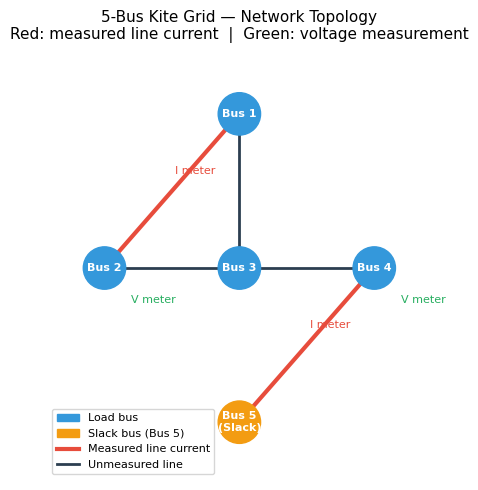

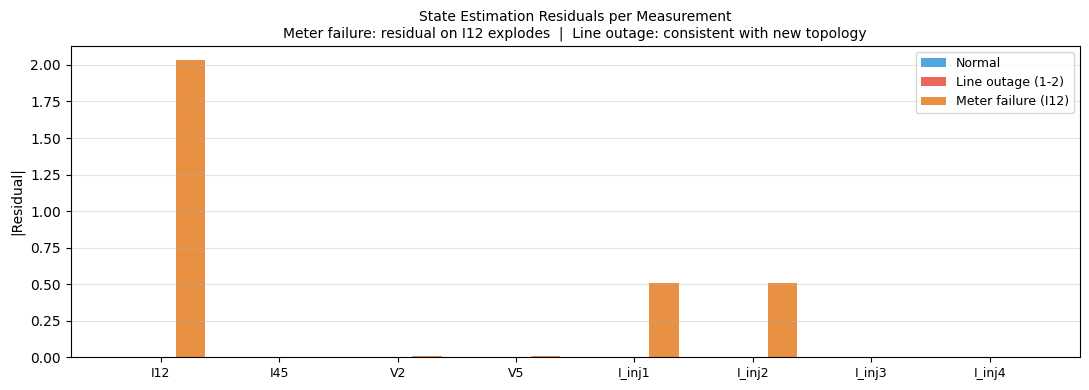

Step 1 done: Network topology + SE residuals


In [16]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np
import warnings
warnings.filterwarnings('ignore')

Y, SlackBus, I = load_network()

# ── Kite grid topology diagram ───────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(7, 5))
ax.set_aspect('equal'); ax.axis('off')

pos = {1:(0.5,0.95), 2:(0.15,0.55), 3:(0.5,0.55), 4:(0.85,0.55), 5:(0.5,0.15)}
edges = [(1,2),(1,3),(2,3),(3,4),(4,5)]
measured_edges = [(1,2),(4,5)]

for a,b in edges:
    x=[pos[a][0],pos[b][0]]; y=[pos[a][1],pos[b][1]]
    lw=3 if (a,b) in measured_edges else 2
    col='#e74c3c' if (a,b) in measured_edges else '#2c3e50'
    ax.plot(x,y,color=col,lw=lw,zorder=1)
    if (a,b) in measured_edges:
        mx,my=(x[0]+x[1])/2,(y[0]+y[1])/2
        ax.annotate('I meter',xy=(mx,my),fontsize=8,color='#e74c3c',
                    ha='center',va='bottom',xytext=(mx+0.06,my+0.04))

for node,(x,y) in pos.items():
    color='#f39c12' if node==SlackBus else '#3498db'
    ax.add_patch(plt.Circle((x,y),0.055,color=color,zorder=2))
    label=f'Bus {node}\n(Slack)' if node==SlackBus else f'Bus {node}'
    ax.text(x,y,label,ha='center',va='center',fontsize=8,
            fontweight='bold',color='white',zorder=3)

for node in [2,4]:
    x,y=pos[node]
    ax.annotate('V meter',xy=(x,y),fontsize=8,color='#27ae60',
                ha='left',va='top',xytext=(x+0.07,y-0.07))

ax.set_xlim(0,1); ax.set_ylim(0,1.1)
ax.set_title('5-Bus Kite Grid — Network Topology\nRed: measured line current  |  Green: voltage measurement',fontsize=11,pad=12)
legend_els=[
    mpatches.Patch(color='#3498db',label='Load bus'),
    mpatches.Patch(color='#f39c12',label='Slack bus (Bus 5)'),
    plt.Line2D([0],[0],color='#e74c3c',lw=3,label='Measured line current'),
    plt.Line2D([0],[0],color='#2c3e50',lw=2,label='Unmeasured line'),
]
ax.legend(handles=legend_els,loc='lower left',fontsize=8)
plt.tight_layout(); plt.show()

# ── SE residuals: normal vs line_outage vs meter_failure ────────────────────
Y_lo = simulate_line_outage(Y,(0,1))
v_lo = _solve_voltages(Y_lo,SlackBus,I)
y12f=-Y_lo[0,1]; y45f=-Y_lo[3,4]
z_lo=np.zeros(8,dtype=complex)
z_lo[0]=y12f*(v_lo[0]-v_lo[1]); z_lo[1]=y45f*(v_lo[4]-v_lo[3])
z_lo[2]=v_lo[1]; z_lo[3]=v_lo[4]; z_lo[4:8]=I

v0,z0,Hx,x0,r0 = compute_baseline(Y,SlackBus,I)
_,r_lo  = run_SE(Y_lo,SlackBus,I,z_lo)
z_mf    = simulate_meter_failure(z0,0,corruption=METER_CORRUPTION)
_,r_mf  = run_SE(Y,SlackBus,I,z_mf)

meas_labels=['I12','I45','V2','V5','I_inj1','I_inj2','I_inj3','I_inj4']
x_pos=np.arange(8); width=0.25
fig,ax=plt.subplots(figsize=(11,4))
ax.bar(x_pos-width, np.abs(r0),  width, label='Normal',              color='#3498db',alpha=0.85)
ax.bar(x_pos,       np.abs(r_lo),width, label='Line outage (1-2)',   color='#e74c3c',alpha=0.85)
ax.bar(x_pos+width, np.abs(r_mf),width, label='Meter failure (I12)', color='#e67e22',alpha=0.85)
ax.set_xticks(x_pos); ax.set_xticklabels(meas_labels,fontsize=9)
ax.set_ylabel('|Residual|',fontsize=10)
ax.set_title('State Estimation Residuals per Measurement\n'
             'Meter failure: residual on I12 explodes  |  Line outage: consistent with new topology',fontsize=10)
ax.legend(fontsize=9); ax.grid(axis='y',alpha=0.35)
plt.tight_layout(); plt.show()
print("Step 1 done: Network topology + SE residuals")


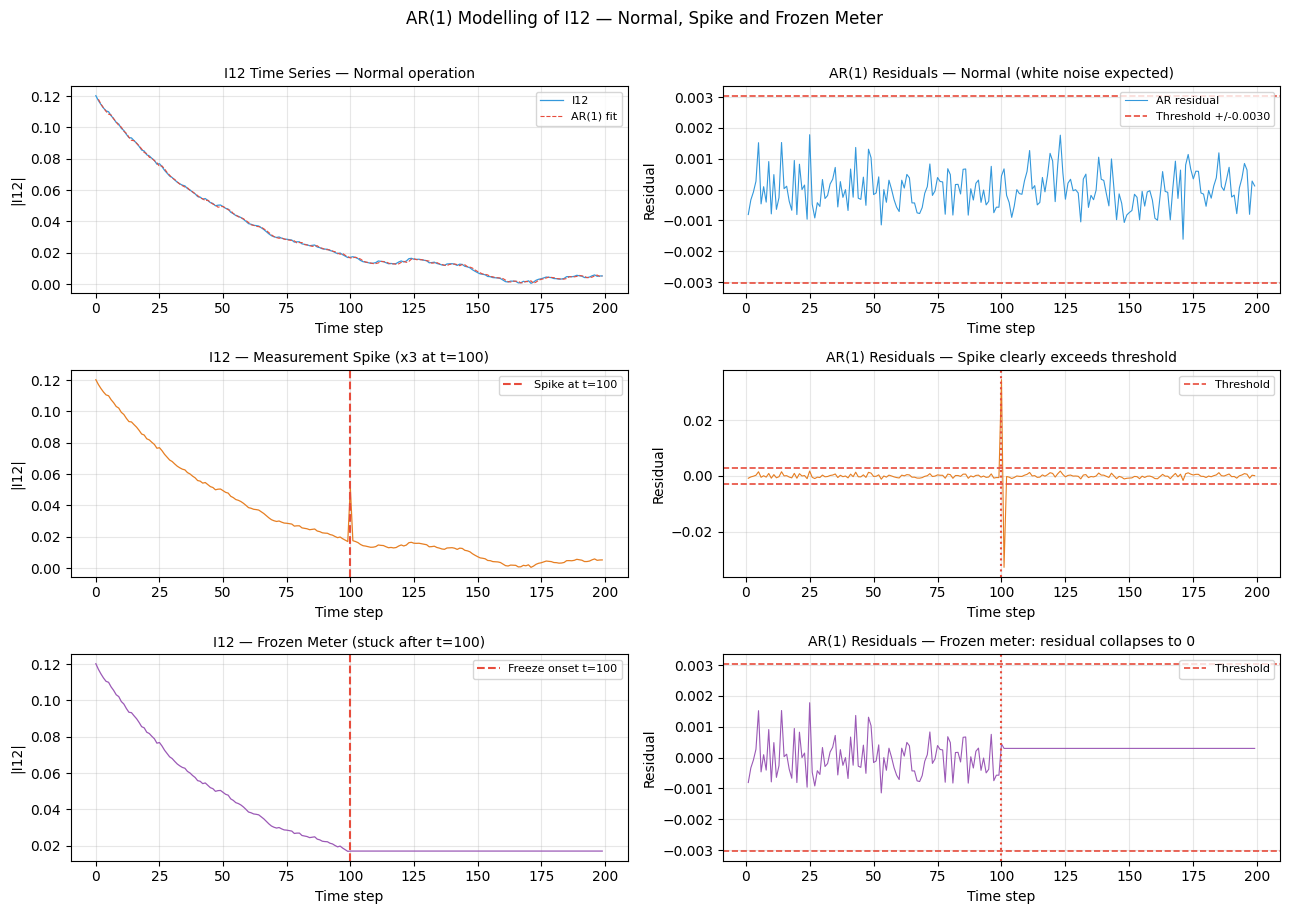

Step 2 done: AR(1) modelling


In [17]:
I123_norm,_ = generate_time_series(Y,SlackBus,I)
a_I,b_I     = fit_AR1(I123_norm)
r_norm,I123_hat = compute_residuals(I123_norm,a_I,b_I)
_,thr_I     = detect_anomalies(r_norm)

I123_spike  = simulate_AR_spike(I123_norm, t_spike=SPIKE_T, factor=SPIKE_FACTOR)
I123_frozen = simulate_AR_frozen(I123_norm, t_start=FROZEN_T)
r_spike,_   = compute_residuals(I123_spike,  a_I, b_I)
r_frozen,_  = compute_residuals(I123_frozen, a_I, b_I)

t = np.arange(len(I123_norm))
fig, axes = plt.subplots(3,2,figsize=(13,9))

axes[0,0].plot(t,I123_norm,color='#3498db',lw=0.9,label='I12')
axes[0,0].plot(t[1:],I123_hat,'--',color='#e74c3c',lw=0.8,label='AR(1) fit')
axes[0,0].set_title('I12 Time Series — Normal operation',fontsize=10)
axes[0,0].set_ylabel('|I12|'); axes[0,0].legend(fontsize=8); axes[0,0].grid(True,alpha=0.3)

axes[0,1].plot(t[1:],r_norm,color='#3498db',lw=0.8,label='AR residual')
axes[0,1].axhline(thr_I, color='#e74c3c',ls='--',lw=1.2,label=f'Threshold +/-{thr_I:.4f}')
axes[0,1].axhline(-thr_I,color='#e74c3c',ls='--',lw=1.2)
axes[0,1].set_title('AR(1) Residuals — Normal (white noise expected)',fontsize=10)
axes[0,1].set_ylabel('Residual'); axes[0,1].legend(fontsize=8); axes[0,1].grid(True,alpha=0.3)

axes[1,0].plot(t,I123_spike,color='#e67e22',lw=0.9)
axes[1,0].axvline(SPIKE_T,color='#e74c3c',ls='--',lw=1.5,label=f'Spike at t={SPIKE_T}')
axes[1,0].set_title('I12 — Measurement Spike (x3 at t=100)',fontsize=10)
axes[1,0].set_ylabel('|I12|'); axes[1,0].legend(fontsize=8); axes[1,0].grid(True,alpha=0.3)

axes[1,1].plot(t[1:],r_spike,color='#e67e22',lw=0.8)
axes[1,1].axhline(thr_I, color='#e74c3c',ls='--',lw=1.2,label='Threshold')
axes[1,1].axhline(-thr_I,color='#e74c3c',ls='--',lw=1.2)
axes[1,1].axvline(SPIKE_T,color='#e74c3c',ls=':',lw=1.5)
axes[1,1].set_title('AR(1) Residuals — Spike clearly exceeds threshold',fontsize=10)
axes[1,1].set_ylabel('Residual'); axes[1,1].legend(fontsize=8); axes[1,1].grid(True,alpha=0.3)

axes[2,0].plot(t,I123_frozen,color='#9b59b6',lw=0.9)
axes[2,0].axvline(FROZEN_T,color='#e74c3c',ls='--',lw=1.5,label=f'Freeze onset t={FROZEN_T}')
axes[2,0].set_title('I12 — Frozen Meter (stuck after t=100)',fontsize=10)
axes[2,0].set_ylabel('|I12|'); axes[2,0].legend(fontsize=8); axes[2,0].grid(True,alpha=0.3)

axes[2,1].plot(t[1:],r_frozen,color='#9b59b6',lw=0.8)
axes[2,1].axhline(thr_I, color='#e74c3c',ls='--',lw=1.2,label='Threshold')
axes[2,1].axhline(-thr_I,color='#e74c3c',ls='--',lw=1.2)
axes[2,1].axvline(FROZEN_T,color='#e74c3c',ls=':',lw=1.5)
axes[2,1].set_title('AR(1) Residuals — Frozen meter: residual collapses to 0',fontsize=10)
axes[2,1].set_ylabel('Residual'); axes[2,1].legend(fontsize=8); axes[2,1].grid(True,alpha=0.3)

for ax in axes.flat: ax.set_xlabel('Time step')
plt.suptitle('AR(1) Modelling of I12 — Normal, Spike and Frozen Meter',fontsize=12,y=1.01)
plt.tight_layout(); plt.show()
print("Step 2 done: AR(1) modelling")


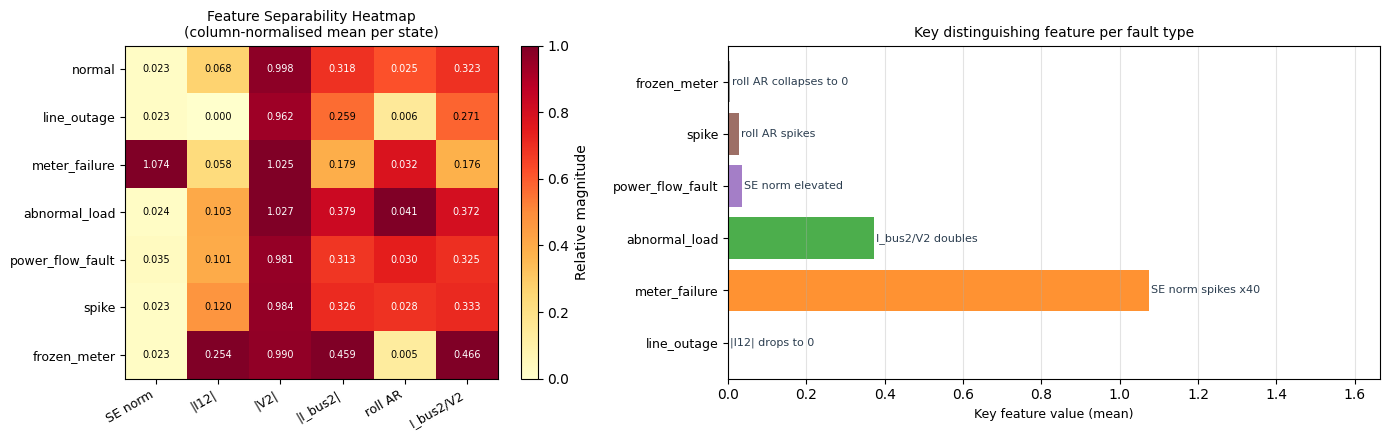

Step 3 done: Feature engineering heatmap


In [18]:
_ar_hist3 = []
_RW = 5
FEAT_NAMES_V2 = ["SE norm","|I12|","|V2|","|I_bus2|","roll AR","I_bus2/V2"]

def _csf_v2_c3(Y_active,SlackBus,I_curr,prev_I12,rng,**kwargs):
    feat,I12_out=compute_step_features(Y_active,SlackBus,I_curr,prev_I12,rng,**kwargs)
    _ar_hist3.append(feat[4])
    rm=max(_ar_hist3[-_RW:])
    iv=feat[3]/max(feat[2],1e-6)
    return np.array([feat[0],feat[1],feat[2],feat[3],rm,iv]),I12_out

def _sim_c3(schedule,rng):
    Ylo=simulate_line_outage(Y,(0,1))
    obs,states=[],[]
    Ic=I.copy(); pI12=None; fval=None
    for sname,n in schedule:
        Ya=Ylo if sname=="line_outage" else Y
        for t in range(n):
            e=(rng.standard_normal(len(Ic))+1j*rng.standard_normal(len(Ic)))*AR_NOISE_STD
            Ic=AR_COEFF*Ic+e; Iu=Ic.copy(); kw={}
            if sname=="meter_failure": kw["meter_fault_idx"]=0
            elif sname=="abnormal_load": Iu[1]*=LOAD_SCALE
            elif sname=="power_flow_fault": kw["pf_v_scale"]=PF_FACTOR
            elif sname=="spike":
                if t==n//2: kw["spike_scale"]=SPIKE_FACTOR
            elif sname=="frozen_meter":
                if t==0:
                    vt=_solve_voltages(Ya,SlackBus,Iu)
                    fval=float(np.abs(Ya[0,1]*(vt[0]-vt[1])))
                kw["frozen_I12"]=fval
            f,I12o=_csf_v2_c3(Ya,SlackBus,Iu,pI12,rng,**kw)
            obs.append(f); states.append(sname); pI12=I12o
    return np.array(obs),states

rng_c3=np.random.default_rng(42)
_ar_hist3.clear()
obs_f,lbl_f=_sim_c3([(s,80) for s in STATE_NAMES],rng_c3)
la_f=np.array(lbl_f)
feat_matrix=np.array([obs_f[la_f==s].mean(axis=0) for s in STATE_NAMES])
feat_norm=feat_matrix/(feat_matrix.max(axis=0)+1e-12)

fig,axes=plt.subplots(1,2,figsize=(14,4.5),gridspec_kw={'width_ratios':[1,1.4]})

im=axes[0].imshow(feat_norm,aspect='auto',cmap='YlOrRd',vmin=0,vmax=1)
axes[0].set_xticks(range(6)); axes[0].set_xticklabels(FEAT_NAMES_V2,rotation=30,ha='right',fontsize=9)
axes[0].set_yticks(range(7)); axes[0].set_yticklabels(STATE_NAMES,fontsize=9)
axes[0].set_title('Feature Separability Heatmap\n(column-normalised mean per state)',fontsize=10)
plt.colorbar(im,ax=axes[0],label='Relative magnitude')
for i in range(7):
    for j in range(6):
        axes[0].text(j,i,f'{feat_matrix[i,j]:.3f}',ha='center',va='center',fontsize=7,
                     color='white' if feat_norm[i,j]>0.6 else 'black')

distinguishing={
    'line_outage'     :(1,'|I12| drops to 0'),
    'meter_failure'   :(0,'SE norm spikes x40'),
    'abnormal_load'   :(5,'I_bus2/V2 doubles'),
    'power_flow_fault':(0,'SE norm elevated'),
    'spike'           :(4,'roll AR spikes'),
    'frozen_meter'    :(4,'roll AR collapses to 0'),
}
colors_bar=plt.cm.tab10(np.linspace(0,0.7,6))
fault_names=list(distinguishing.keys())
feat_vals=[feat_matrix[STATE_NAMES.index(f),fi] for f,(fi,_) in distinguishing.items()]
annots=[ann for _,(_,ann) in distinguishing.items()]

bars=axes[1].barh(range(6),feat_vals,color=colors_bar,alpha=0.85)
axes[1].set_yticks(range(6)); axes[1].set_yticklabels(fault_names,fontsize=9)
axes[1].set_xlabel('Key feature value (mean)',fontsize=9)
axes[1].set_title('Key distinguishing feature per fault type',fontsize=10)
for bar,ann in zip(bars,annots):
    axes[1].text(bar.get_width()+0.005,bar.get_y()+bar.get_height()/2,
                 ann,va='center',fontsize=8,color='#2c3e50')
axes[1].grid(axis='x',alpha=0.35)
axes[1].set_xlim(0,feat_matrix.max()*1.55)
plt.tight_layout(); plt.show()
print("Step 3 done: Feature engineering heatmap")


In [ ]:
from hmmlearn import hmm as hmmlib
import warnings; warnings.filterwarnings('ignore')

_ar_hist4 = []
_RW4 = 5
FEAT_NAMES_V2 = ["SE norm","|I12|","|V2|","|I_bus2|","roll AR","I_bus2/V2"]
state_colors = plt.cm.tab10(np.linspace(0,0.7,len(STATE_NAMES)))

def _csf_v2_c4(Y_active,SlackBus,I_curr,prev_I12,rng,**kwargs):
    feat,I12_out=compute_step_features(Y_active,SlackBus,I_curr,prev_I12,rng,**kwargs)
    _ar_hist4.append(feat[4])
    rm=max(_ar_hist4[-_RW4:])
    iv=feat[3]/max(feat[2],1e-6)
    return np.array([feat[0],feat[1],feat[2],feat[3],rm,iv]),I12_out

def _sim_c4(schedule,rng):
    Ylo=simulate_line_outage(Y,(0,1))
    obs,states=[],[]
    Ic=I.copy(); pI12=None; fval=None
    for sname,n in schedule:
        Ya=Ylo if sname=="line_outage" else Y
        for t in range(n):
            e=(rng.standard_normal(len(Ic))+1j*rng.standard_normal(len(Ic)))*AR_NOISE_STD
            Ic=AR_COEFF*Ic+e; Iu=Ic.copy(); kw={}
            if sname=="meter_failure": kw["meter_fault_idx"]=0
            elif sname=="abnormal_load": Iu[1]*=LOAD_SCALE
            elif sname=="power_flow_fault": kw["pf_v_scale"]=PF_FACTOR
            elif sname=="spike":
                if t==n//2: kw["spike_scale"]=SPIKE_FACTOR
            elif sname=="frozen_meter":
                if t==0:
                    vt=_solve_voltages(Ya,SlackBus,Iu)
                    fval=float(np.abs(Ya[0,1]*(vt[0]-vt[1])))
                kw["frozen_I12"]=fval
            f,I12o=_csf_v2_c4(Ya,SlackBus,Iu,pI12,rng,**kw)
            obs.append(f); states.append(sname); pI12=I12o
    return np.array(obs),states

schedule=[
    ("normal",          SIM_T_PER_STATE),
    ("line_outage",     SIM_T_PER_STATE),
    ("normal",          SIM_T_PER_STATE//2),
    ("meter_failure",   SIM_T_PER_STATE),
    ("normal",          SIM_T_PER_STATE//2),
    ("abnormal_load",   SIM_T_PER_STATE),
    ("power_flow_fault",SIM_T_PER_STATE),
    ("normal",          SIM_T_PER_STATE//2),
    ("normal",          37),
    ("spike",           3),
    ("normal",          40),
    ("frozen_meter",    SIM_T_PER_STATE),
    ("normal",          SIM_T_PER_STATE//2),
]
T_total=sum(n for _,n in schedule)

rng4=np.random.default_rng(SIM_SEED)
_ar_hist4.clear()
obs_seq,true_labels=_sim_c4(schedule,rng4)
true_arr=np.array(true_labels)

# Calibrate HMM
n_states=len(STATE_NAMES)
cal_means,cal_covars={},{}
for s in STATE_NAMES:
    mask=true_arr==s
    if not mask.any():
        cal_means[s]=[0.02,0.09,1.0,0.3,0.02,0.3]; cal_covars[s]=[0.01**2]*6; continue
    seg=obs_seq[mask]
    if s=="spike":
        bi=np.argmax(seg[:,4]); mu=seg[bi]; sigma=np.maximum(seg.var(axis=0)*50,1e-6)
    else:
        mu=seg.mean(axis=0); sigma=np.maximum(seg.var(axis=0),1e-8)
    cal_means[s]=mu.tolist(); cal_covars[s]=sigma.tolist()

means_arr =np.array([cal_means[s]  for s in STATE_NAMES],dtype=float)
covars_arr=np.array([cal_covars[s] for s in STATE_NAMES],dtype=float)
off=(1.0-HMM_SELF_PROB)/max(n_states-1,1)
A=np.full((n_states,n_states),off); np.fill_diagonal(A,HMM_SELF_PROB)
model=hmmlib.GaussianHMM(n_components=n_states,covariance_type='diag',n_iter=0,init_params='')
model.startprob_=np.ones(n_states)/n_states
model.transmat_=A; model.means_=means_arr; model.covars_=covars_arr
model.fit(means_arr,lengths=[1]*n_states)
state_map={i:s for i,s in enumerate(STATE_NAMES)}

_,decoded_int=model.decode(obs_seq)
predicted_labels=[state_map[i] for i in decoded_int]
pred_arr=np.array(predicted_labels)
overall=np.mean(pred_arr==true_arr)

per_state_acc={}
for s in STATE_NAMES:
    mask=true_arr==s
    if mask.any(): per_state_acc[s]=np.mean(pred_arr[mask]==s)

print(f"Overall accuracy: {overall:.1%}")
for s,acc in per_state_acc.items():
    print(f"  {s:20s}: {acc:.1%}")

# ── Accuracy bar chart + confusion matrix ────────────────────────────────────
fig,axes=plt.subplots(1,2,figsize=(13,4.5))

bars=axes[0].bar(range(n_states),[per_state_acc.get(s,0) for s in STATE_NAMES],
                  color=state_colors,alpha=0.9,edgecolor='white',lw=0.5)
axes[0].set_xticks(range(n_states)); axes[0].set_xticklabels(STATE_NAMES,rotation=30,ha='right',fontsize=9)
axes[0].set_ylabel('Detection accuracy',fontsize=10); axes[0].set_ylim(0,1.08)
axes[0].axhline(overall,color='#2c3e50',ls='--',lw=1.5,label=f'Overall: {overall:.1%}')
axes[0].set_title('Viterbi Detection Accuracy per Fault Type',fontsize=11)
axes[0].legend(fontsize=9); axes[0].grid(axis='y',alpha=0.35)
for bar,s in zip(bars,STATE_NAMES):
    acc=per_state_acc.get(s,0)
    axes[0].text(bar.get_x()+bar.get_width()/2,acc+0.01,f'{acc:.0%}',
                 ha='center',va='bottom',fontsize=9,fontweight='bold')

conf=np.zeros((n_states,n_states),dtype=int)
for tt,pp in zip(true_arr,pred_arr):
    conf[STATE_NAMES.index(tt),STATE_NAMES.index(pp)]+=1
conf_norm=conf/(conf.sum(axis=1,keepdims=True)+1e-9)
im=axes[1].imshow(conf_norm,cmap='Blues',vmin=0,vmax=1)
axes[1].set_xticks(range(n_states)); axes[1].set_yticks(range(n_states))
axes[1].set_xticklabels(STATE_NAMES,rotation=40,ha='right',fontsize=8)
axes[1].set_yticklabels(STATE_NAMES,fontsize=8)
axes[1].set_xlabel('Predicted state',fontsize=9); axes[1].set_ylabel('True state',fontsize=9)
axes[1].set_title('Confusion Matrix (row-normalised)',fontsize=11)
for i in range(n_states):
    for j in range(n_states):
        val=conf_norm[i,j]
        axes[1].text(j,i,f'{val:.0%}',ha='center',va='center',fontsize=8,
                     color='white' if val>0.5 else '#2c3e50')
plt.colorbar(im,ax=axes[1])
plt.tight_layout(); plt.show()

# ── Viterbi timeline ─────────────────────────────────────────────────────────
state_to_int={s:i for i,s in enumerate(STATE_NAMES)}
true_int=[state_to_int[s] for s in true_labels]
pred_int=[state_to_int[s] for s in predicted_labels]
t_axis=np.arange(T_total)

fig,axes=plt.subplots(4,1,figsize=(15,10),sharex=True)

ax=axes[0]
for fi,fname in enumerate(FEAT_NAMES_V2):
    ax.plot(t_axis,obs_seq[:,fi],label=fname,lw=0.8,alpha=0.85)
ax.set_ylabel('Feature value',fontsize=9)
ax.set_title('6-Feature Observation Vector over Time',fontsize=10)
ax.legend(fontsize=7,ncol=6,loc='upper right'); ax.grid(True,alpha=0.25)

ax=axes[1]
ax.plot(t_axis,obs_seq[:,0],color='#2c7bb6',lw=0.85)
ax.set_ylabel('SE norm',fontsize=9)
ax.set_title('SE Residual Norm — large spike identifies meter_failure',fontsize=10)
ax.grid(True,alpha=0.25)

ax=axes[2]
for t in range(T_total):
    ax.axvspan(t,t+1,facecolor=state_colors[true_int[t]],alpha=0.85,linewidth=0)
ax.set_yticks(range(n_states)); ax.set_yticklabels(STATE_NAMES,fontsize=7)
ax.set_title('Ground-Truth Hidden State',fontsize=10); ax.grid(axis='x',alpha=0.2)

ax=axes[3]
for t in range(T_total):
    ax.axvspan(t,t+1,facecolor=state_colors[pred_int[t]],alpha=0.85,linewidth=0)
ax.set_yticks(range(n_states)); ax.set_yticklabels(STATE_NAMES,fontsize=7)
ax.set_title(f'Viterbi Decoded State  (overall accuracy = {overall:.1%})',fontsize=10)
ax.set_xlabel('Time step',fontsize=9); ax.grid(axis='x',alpha=0.2)

patches=[mpatches.Patch(color=state_colors[i],label=s) for i,s in enumerate(STATE_NAMES)]
axes[3].legend(handles=patches,ncol=4,loc='lower right',fontsize=7)
plt.tight_layout(); plt.show()
print(f"Step 4 done: HMM results. Overall accuracy: {overall:.1%}")
